# Retail Sales Performance Analysis

Dataset: Superstore Dataset
Source: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

Objectives:

- Analyze sales performance, profitability, and trends.
- Identify top categories/sub-categories and regional performance.
- Track growth over time and seasonality.

Tools:

- pandas
- matplotlib


## Data Loading and Cleaning


### Data Loading


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

### Data Cleaning


Look at structure

Things to check:

- column names
- strange formatting
- unexpected values


In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Check data types


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
# Convert date values to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

Check missing values


In [6]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Check duplicates

Duplicate records can inflate results


In [7]:
df.duplicated().sum()

np.int64(0)

Check value ranges

Look for suspicious values


In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2016-04-30 00:07:12.259355,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,2016-05-03 23:06:58.571142,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
Postal Code,9994.0,55190.379428,1040.0,23223.0,56430.5,90008.0,99301.0,32063.69335
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108


This dataset does not contain significant data quality issues.

Therefore, the cleaning process mainly consisted of reviewing the data structure and ensuring that all variables have the appropriate data types to facilitate analysis.


## Exploratory Data Analysis (EDA)


Some questions we can answer

Sales and Profit:

- Which categories have the best sales
- Which categories give the most profits

Customer:

- Which customer segment gives the most profit
- What makes a customer buy something again in the store (discounts, product categories, delivery time, etc.)

Time:

- When can we see the most sales and profits

Discounts:

- Are the discounts improve profits?
- Are the discounts afecting future sales in some product?
- Is there a time to time to give discounts (day, week, month)


### Sales vs Profit by Category


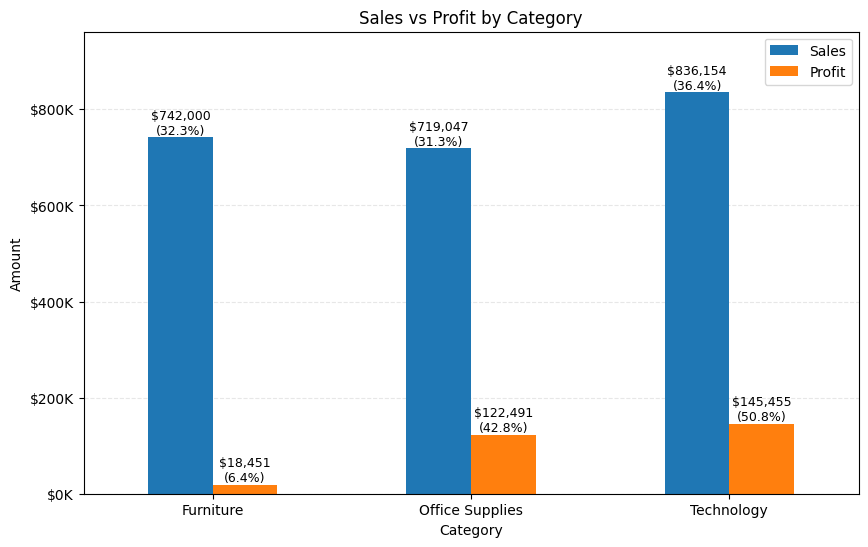

In [9]:
# sales and profit by category
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()

# create the plot view
fig, ax = plt.subplots(figsize=(10, 6))
category_summary.plot(kind="bar", ax=ax)

# setting labels
ax.set_title("Sales vs Profit by Category")
ax.set_ylabel("Amount")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000:,.0f}K'))

# setting grid
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# add more space at the top of the grapth to display texts above the bars
max_value = category_summary.max().max()
ax.set_ylim(0, max_value * 1.15)

# calculate the totals for sales and profit
total_sales = category_summary["Sales"].sum()
total_profit = category_summary["Profit"].sum()

# add totals and share values above each bar
for container, metric in zip(ax.containers, ["Sales", "Profit"]):
    total = total_sales if metric == "Sales" else total_profit

    for bar in container:
        height = bar.get_height()
        percent = height / total * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"${height:,.0f}\n({percent:.1f}%)",
            ha="center",
            va="bottom",
            color="black",
            fontsize=9
        )

plt.show()

- Technology represents the most profit (~51% of the total profits)
- Office Supplies is the second most profitable category
- Furniture represents a very little profit compared to its sales. Only ~6.4% of the total profit compared to ~32% of the total sales


### Sales vs Profit by Customer Segment


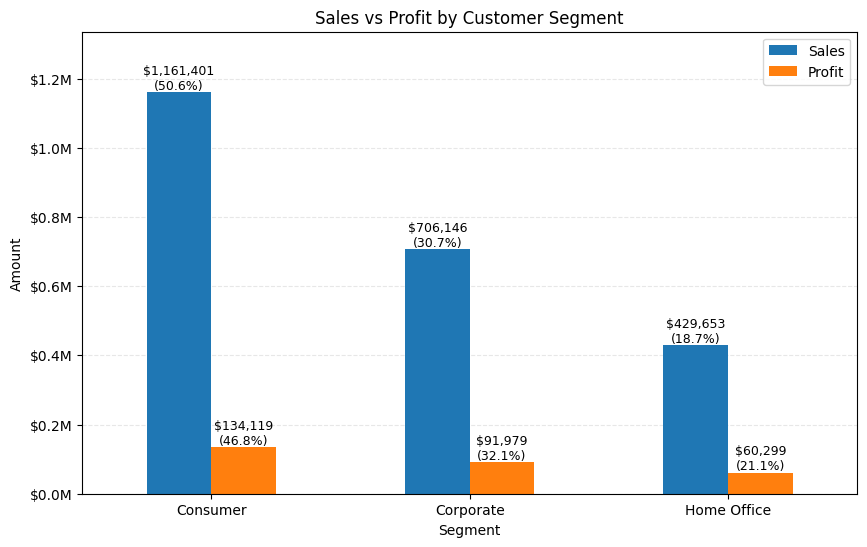

In [10]:
# customer segment analysis
customer_segment_summary = df.groupby("Segment")[["Sales", "Profit"]].sum()

# create the plot view
fig, ax = plt.subplots(figsize=(10, 6))
customer_segment_summary.plot(kind="bar", ax=ax)

# setting labels
ax.set_title("Sales vs Profit by Customer Segment")
ax.set_ylabel("Amount")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))

# setting grid
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# add more space at the top of the grapth to display texts above the bars
max_value = customer_segment_summary.max().max()
ax.set_ylim(0, max_value*1.15)

# calculate the totals for sales and profit
total_sales = customer_segment_summary["Sales"].sum()
total_profit = customer_segment_summary["Profit"].sum()

# add totals and share values above each bar
for container, metric in zip(ax.containers, ["Sales", "Profit"]):
    total = total_sales if metric == "Sales" else total_profit

    for bar in container:
        height = bar.get_height()
        percent = height / total * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"${height:,.0f}\n({percent:.1f}%)",
            ha="center",
            va="bottom",
            color="black",
            fontsize=9
        )

plt.show()

### Identify Repeat Customers


In [11]:
# intentify customers who bought more than once

# for each (customer) count unique (order ids)
repeat_customers = df.groupby("Customer ID")["Order ID"].nunique().sort_values(ascending=False)

repeat_customers

Customer ID
EP-13915    17
SH-19975    13
NS-18640    13
PG-18820    13
ZC-21910    13
            ..
SM-20905     1
PH-18790     1
MG-18205     1
CJ-11875     1
LD-16855     1
Name: Order ID, Length: 793, dtype: int64

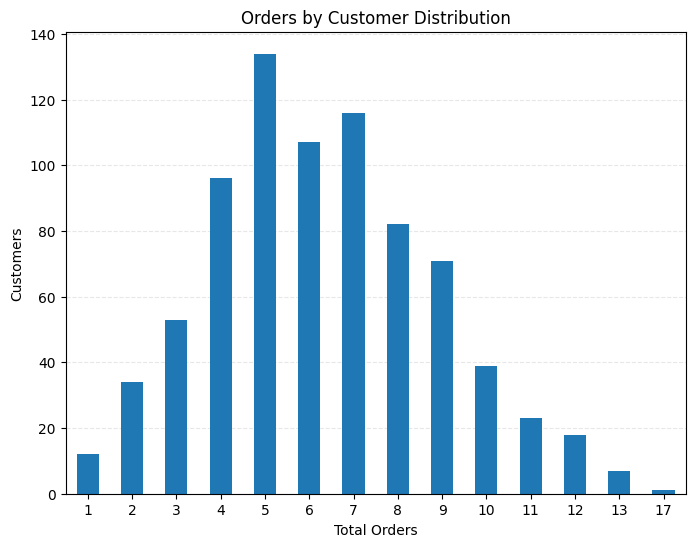

In [12]:
# plot repeat customers distribution
repeat_customers_distribution = repeat_customers.value_counts().sort_index()

# create the plot view
fig, ax = plt.subplots(figsize=(8, 6))
repeat_customers_distribution.plot(kind="bar", ax=ax)

# setting labels
ax.set_title("Orders by Customer Distribution")
ax.set_xlabel("Total Orders")
ax.set_ylabel("Customers")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# setting grid
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.show()

In [13]:
repeat_customers.reset_index().describe().T

,count,mean,std,min,25%,50%,75%,max
Order ID,793.0,6.31652,2.550885,1.0,5.0,6.0,8.0,17.0


## ...


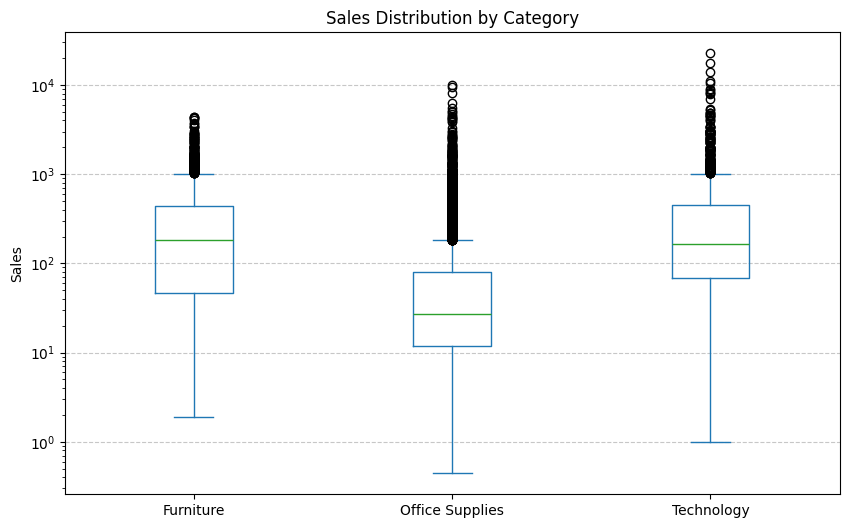

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
df.plot(column="Sales", by="Category", kind="box", ax=ax)

ax.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.7)

ax.set_title("Sales Distribution by Category")
ax.set_ylabel("Sales")

plt.show()

In [15]:
df.describe(include='all').T.sort_values("unique")

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,9994,3,Office Supplies,6026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,9994,4,West,3203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-Category,9994,17,Binders,1523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,9994,49,California,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# totals
total_sales = df["Sales"].sum()
total_per_year = df.groupby(df["Order Date"].dt.to_period("Y"))["Sales"].sum().reset_index()

# calculate growth over years
total_per_year["Growth"] = total_per_year["Sales"].diff().fillna(0)
total_per_year["Percent Growth"] = total_per_year["Sales"].pct_change().fillna(0) * 100

total_per_year

,Order Date,Sales,Growth,Percent Growth
0,2014,484247.4981,0.0000,0.000000
1,2015,470532.5090,-13714.9891,-2.832227
2,2016,609205.5980,138673.0890,29.471521
3,2017,733215.2552,124009.6572,20.355962


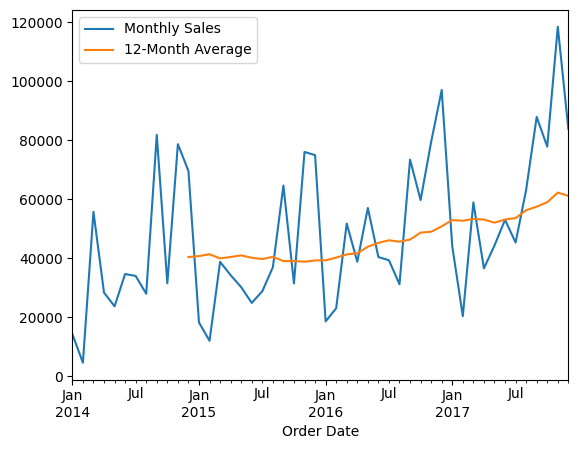

In [17]:
# plot sales by time
sales_by_time = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

rolling_mean_12 = sales_by_time.rolling(12).mean()
sales_by_time.plot(label="Monthly Sales")
rolling_mean_12.plot(label="12-Month Average")

plt.legend()

<Axes: >

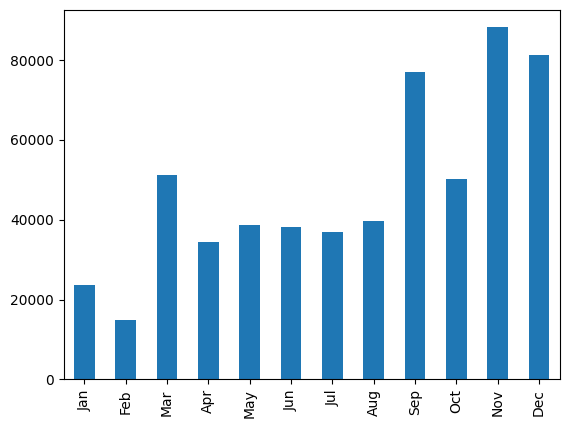

In [18]:
# average sales by month of the year
avg_monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .groupby(lambda x: x.month)
    .mean()
)
# correct indexes
avg_monthly_sales.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

avg_monthly_sales.plot(kind="bar")

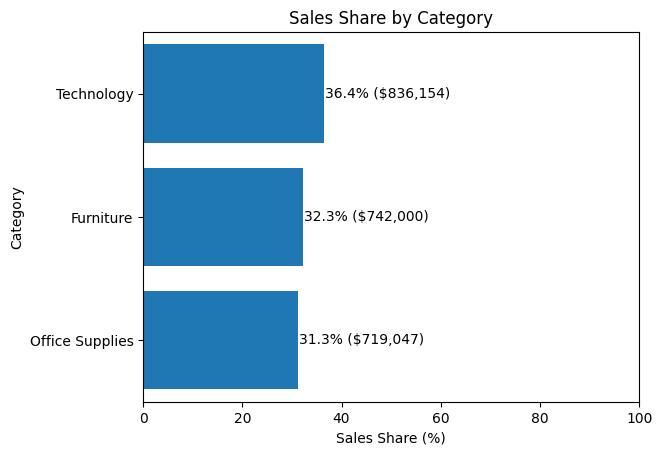

In [19]:
# sales by category
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False).reset_index()
sales_by_category["Share"] = sales_by_category["Sales"] / df["Sales"].sum() * 100

ax = sales_by_category.plot(
    kind="barh",
    x="Category",
    y="Share",
    legend=False
)

bars = ax.barh(
    sales_by_category["Category"],
    sales_by_category["Share"]
)

for bar, sales in zip(bars, sales_by_category["Sales"]):
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}% (${sales:,.0f})",
        va="center"
    )

plt.xlabel("Sales Share (%)")
plt.title("Sales Share by Category")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()

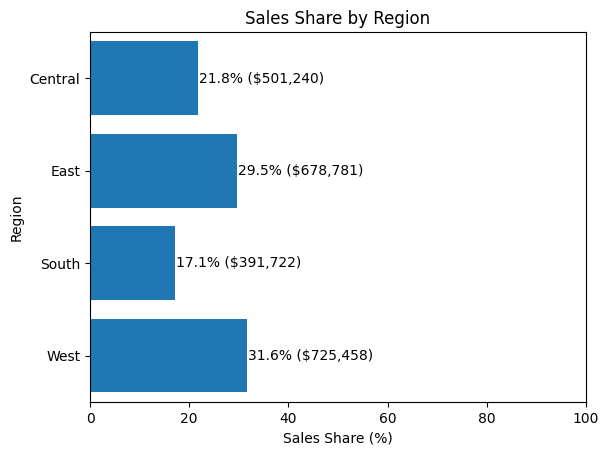

In [20]:
# sales by region
sales_by_region = df.groupby("Region")["Sales"].sum().reset_index()
sales_by_region["Share"] = sales_by_region["Sales"] / df["Sales"].sum() * 100

ax = sales_by_region.plot(
    kind="barh",
    x="Region",
    y="Share",
    legend=False
)

bars = ax.barh(
    sales_by_region["Region"],
    sales_by_region["Share"]
)

for bar, sales in zip(bars, sales_by_region["Sales"]):
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}% (${sales:,.0f})",
        va="center"
    )

plt.xlabel("Sales Share (%)")
plt.title("Sales Share by Region")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()

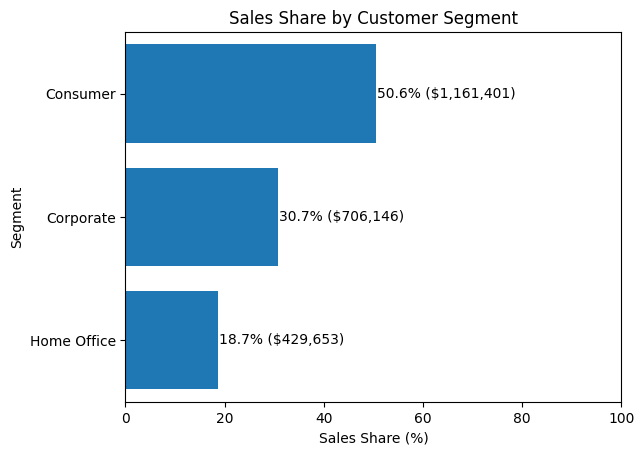

In [21]:
# sales by customer segment
sales_by_customer_segment = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False).reset_index()
sales_by_customer_segment["Share"] = sales_by_customer_segment["Sales"] / df["Sales"].sum() * 100

ax = sales_by_customer_segment.plot(
    kind="barh",
    x="Segment",
    y="Share",
    legend=False
)

bars = ax.barh(
    sales_by_customer_segment["Segment"],
    sales_by_customer_segment["Share"]
)

for bar, sales in zip(bars, sales_by_customer_segment["Sales"]):
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}% (${sales:,.0f})",
        va="center"
    )

plt.xlabel("Sales Share (%)")
plt.title("Sales Share by Customer Segment")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.show()

In [22]:
# top 10 products by revenue
top_revenue_products = (
    df.groupby(["Product Name", "Category", "Sub-Category"])["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)
top_revenue_products["Share"] = top_revenue_products["Sales"] / df["Sales"].sum() * 100

top_revenue_products

,Product Name,Category,Sub-Category,Sales,Share
0,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,2.681517
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,1.195080
2,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,0.985481
3,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.576,0.952053
4,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.479,0.862941
5,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19024.500,0.828160
6,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,0.820115
7,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,18374.895,0.799882
8,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,0.782042
9,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.312,0.741351


In [23]:
# top 10 sub-categories
top_revenue_subcategories = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)

top_revenue_subcategories["Share"] = top_revenue_subcategories["Sales"] / df["Sales"].sum() * 100

top_revenue_subcategories

,Sub-Category,Sales,Share
0,Phones,330007.0540,14.365616
1,Chairs,328449.1030,14.297796
2,Storage,223843.6080,9.744190
3,Tables,206965.5320,9.009466
4,Binders,203412.7330,8.854808
5,Machines,189238.6310,8.237792
6,Accessories,167380.3180,7.286273
7,Copiers,149528.0300,6.509140
8,Bookcases,114879.9963,5.000869
9,Appliances,107532.1610,4.681008


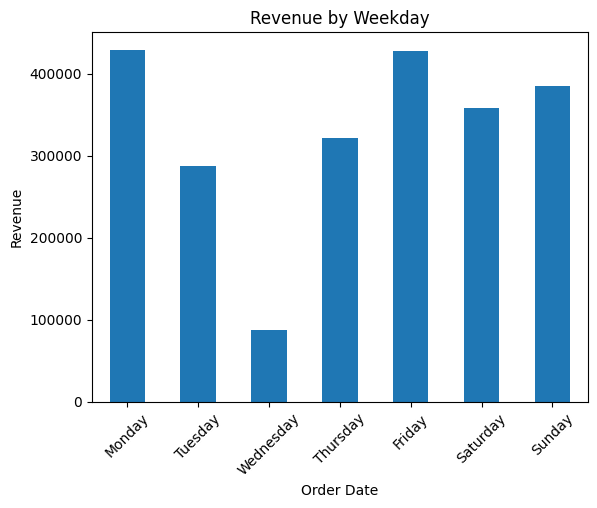

In [24]:
# revenue by weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
revenue_by_weekday = (
    df.groupby(df["Order Date"].dt.day_name())["Sales"]
    .sum()
    .reindex(weekday_order)
)

revenue_by_weekday.plot(kind="bar", title="Revenue by Weekday")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()